In [36]:
import warnings
warnings.filterwarnings("ignore")

from flonacomldft.utils.io_utils import (
    get_path,
    load_pickle_file,
)

from flonacomldft.utils.diagnostics import avg_windows

import seaborn as sns
import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

size=18
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

## DFT Adaptive sampling simulations

In [224]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
ids_is0 = [25072550, 25128620, 25222540, 25222570]
ids_is1 = [25072551, 25128621, 25222541, 25222571, 25320981]

In [225]:
get_adaptive_simulation = lambda isomer, number_id, path: load_pickle_file("results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(isomer, number_id, isomer, number_id), path)

In [226]:
adaptive_is0 = [get_adaptive_simulation(0, ids_is0[i], path) for i in range(len(ids_is0))]
adaptive_is1 = [get_adaptive_simulation(1, ids_is1[i], path) for i in range(len(ids_is1))]

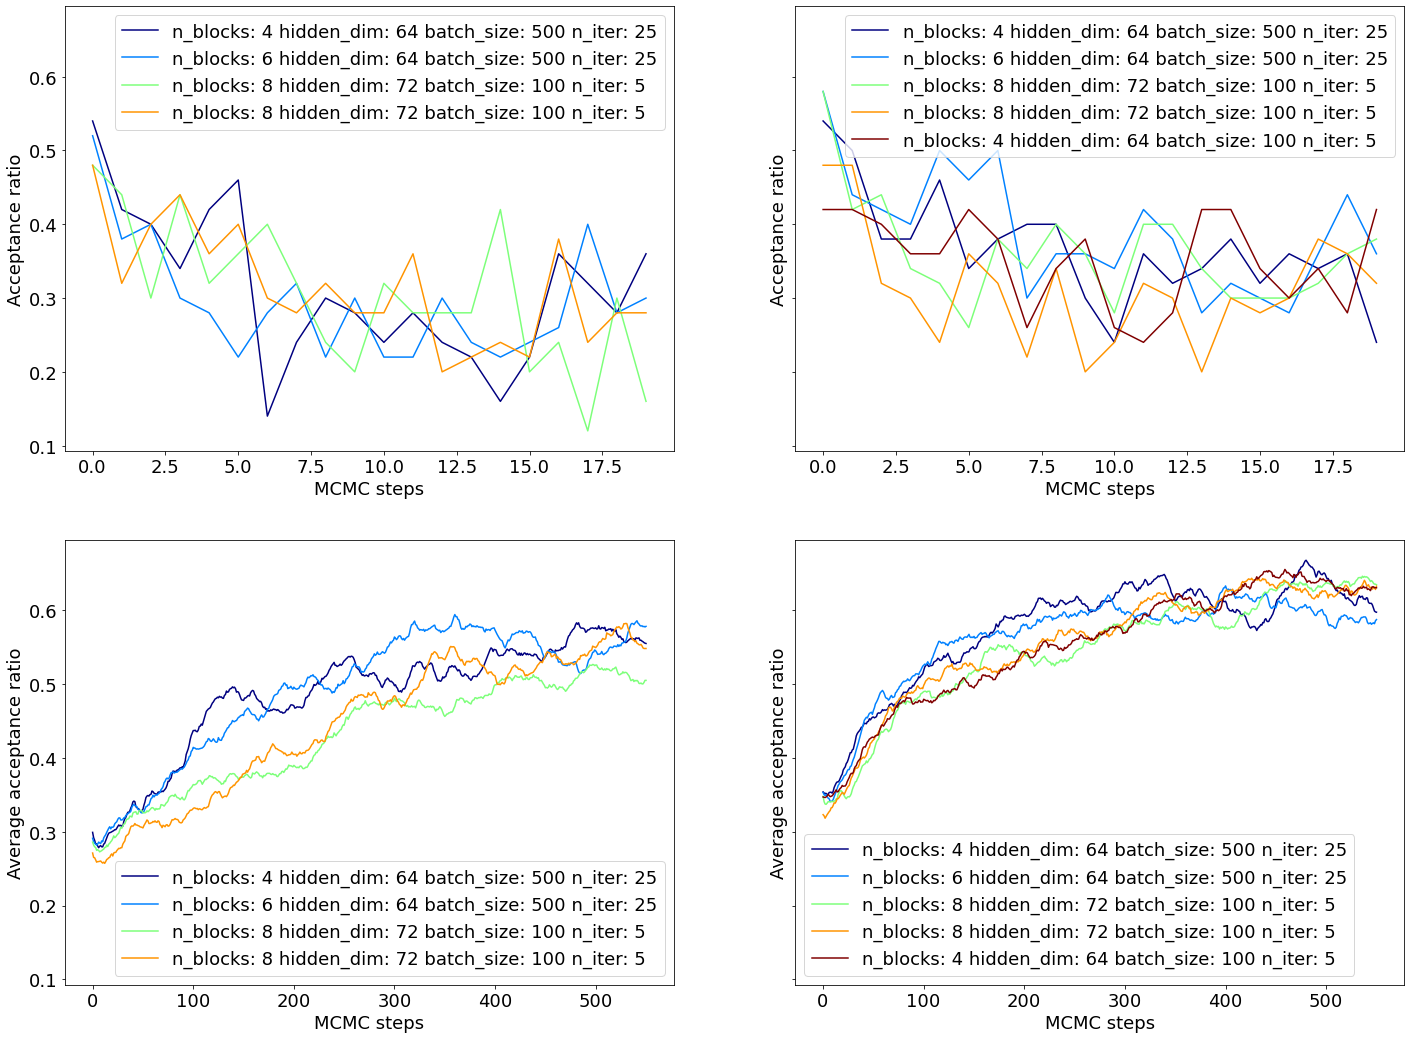

In [74]:
window = 50

all_simulation_accs = []

fig, axs = plt.subplots(2, 2, figsize=(24, 18), sharey=True)

color = cm.jet(np.linspace(0, 1, len(adaptive)))

for j, adaptive in enumerate([adaptive_is0, adaptive_is1]):

    for i in range(len(adaptive)):
    
        simulation_label = "n_blocks: "+str(adaptive[i]["args"]["n_blocks"])
        simulation_label = simulation_label + " hidden_dim: "+str(adaptive[i]["args"]["hidden_dim"])
        simulation_label = simulation_label + " batch_size: "+str(adaptive[i]["args"]["batch_size"])
        simulation_label = simulation_label + " n_iter: "+str(adaptive[i]["args"]["n_iter"])

        accs = torch.cat(adaptive[i]["accs"]).mean(dim=1)
        all_simulation_accs.append(accs.clone())

        axs[0][j].plot(accs[:adaptive[i]["args"]["n_steps"]], c=color[i], label=simulation_label)
    
        accs_avg = avg_windows(accs, window_size=window, axis=1)
    
        axs[1][j].plot(accs_avg, c=color[i], label=simulation_label)

    axs[0][j].set_xlabel("MCMC steps")
    axs[1][j].set_xlabel("MCMC steps")
    
    axs[0][j].set_ylabel("Acceptance ratio")
    axs[1][j].set_ylabel("Average acceptance ratio")
        
    axs[0][j].legend()
    axs[1][j].legend()

In [169]:
from ase.io import read
from ase.units import kB
from flonacomldft.internal_coordinates import Coordinates_mapping

def load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer=None):

    ag6_proposals = []
    for chain in range(n_chains):
        for step in range(n_steps):
            print("ag6_{:d}_{:d}_{:d}.out".format(n_run, step, chain))
            ag6_proposals.append(read("{:s}DFTAdaptive/ag6_{:d}_{:d}_{:d}.out".format(path, n_run, step, chain)))

    coord_mapping = Coordinates_mapping()

    zmat = coord_mapping.get_internal_from_trajectory(ag6_proposals, isomer=isomer, temperature=300)
    xs = coord_mapping.get_real_centered_from_internal(zmat[:, :12], isomer=isomer, energies=zmat[:, 12])        
    
    return xs, zmat, ag6_proposals

def get_participation_ratio_from_dft_proposals(xs, us, model, kB, T):
    
    n_prop = xs.shape[0]
    
    log_weight = -us.squeeze()/(kB*T) + model.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0)
    
    return torch.exp(-log_ratio) / n_prop  

In [242]:
molecules_path = lambda isomer, number_id: "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2/results_adaptive_is{:d}_{:d}/".format(isomer, number_id)

In [228]:
ids_is0

[25072550, 25128620, 25222540, 25222570]

In [268]:
def compute_part_ratios_per_adaptive(adaptive, number_id, isomer):

    part_ratios = []

    n_runs = adaptive["args"]["n_runs"]
    n_chains = adaptive["args"]["n_runs"]
    n_steps = adaptive["args"]["n_steps"]

    for n_run in range(n_runs):
    
        model = adaptive["dict_flows_training"][n_run][0]['model']
        xs = load_proposal_from_flow(molecules_path(isomer, number_id), n_run, n_chains, n_steps, isomer)[0]

        part_ratio = get_participation_ratio_from_dft_proposals(xs[0].float(), xs[2].float(), model, kB, 300)
    
        part_ratios.append(part_ratio)
        
    mcmc_steps = list(range(0, n_runs*n_steps, n_steps))
        
    return part_ratios, mcmc_steps

In [269]:
part_ratios_is0, mcmc_steps_is0 = compute_part_ratios_per_adaptive(adaptive_is0[0], ids_is0[0], 0)

In [270]:
part_ratios_is1, mcmc_steps_is1 = compute_part_ratios_per_adaptive(adaptive_is1[0], ids_is1[0], 1)

Text(0, 0.5, 'participation ratio')

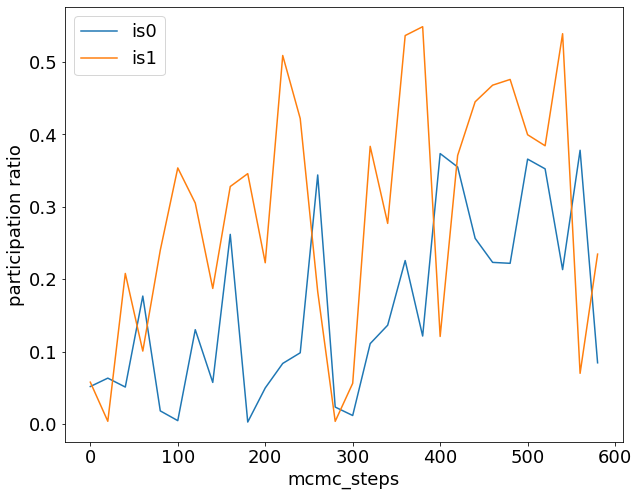

In [272]:
plt.figure(figsize=(10, 8))
plt.plot(range(0, 30*20, 20), torch.stack(part_ratios_is0).detach(), label="is0")
plt.plot(range(0, 30*20, 20), torch.stack(part_ratios_is1).detach(), label="is1")
plt.legend()
plt.xlabel("mcmc_steps")
plt.ylabel("participation ratio")

## How participation ratio looks like with NO training!

In [121]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/3-test-flow-no-training"

#mh_is0_no_training = load_pickle_file("results_metropolis_is0_2552230/is0_mcmc_dic_2552230.pkl", path) 
#mh_is1_no_training = load_pickle_file("results_metropolis_is1_2552269/is1_mcmc_dic_2552269.pkl", path) 

mh_is0_no_training = load_pickle_file("results_metropolis_is0_2553700/is0_mcmc_dic_2553700.pkl", path) 
mh_is1_no_training = load_pickle_file("results_metropolis_is1_2553715/is1_mcmc_dic_2553715.pkl", path) 

In [122]:
accs_is0 = mh_is0_no_training["accs"].mean(dim=1)
accs_is1 = mh_is1_no_training["accs"].mean(dim=1)

Text(0, 0.5, 'Acceptance ratio')

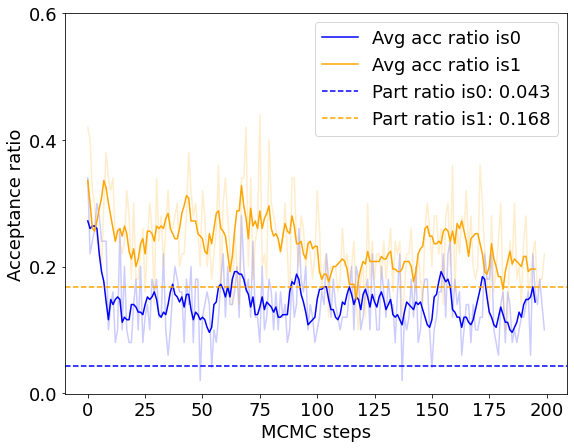

In [123]:
plt.figure(figsize=(9, 7))
plt.plot(accs_is0, c='blue', alpha=0.2)
plt.plot(accs_is1, c='orange', alpha=0.2)
plt.plot(avg_windows(accs_is0, 5, 1), c='blue', label='Avg acc ratio is0')
plt.plot(avg_windows(accs_is1, 5, 1), c='orange', label='Avg acc ratio is1')
plt.axhline(0.043, c='blue', linestyle="dashed", label='Part ratio is0: 0.043')
plt.axhline(0.168, c='orange', linestyle="dashed", label='Part ratio is1: 0.168')
plt.legend()
plt.yticks(np.linspace(0., 0.6, 4))
plt.xlabel("MCMC steps")
plt.ylabel("Acceptance ratio")

In [124]:
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import plot_energy_surface

In [125]:
coord_mapping = Coordinates_mapping()

In [126]:
xs_is0 = mh_is0_no_training['xs']
xs_is0_flatten = xs_is0.reshape(-1, 12)

xs_is1 = mh_is1_no_training['xs']
xs_is1_flatten = xs_is1.reshape(-1, 12)

In [44]:
cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0_flatten, isomer=0)
cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1_flatten, isomer=1)

(2.0, 2.65)

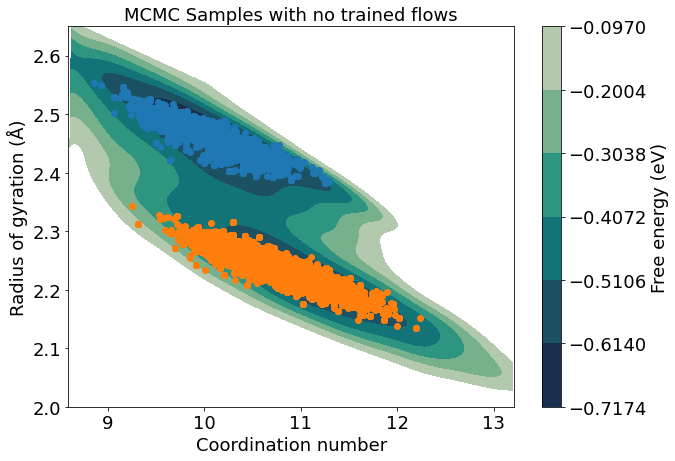

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plot_energy_surface(fig=fig, ax=ax)
ax.scatter(*cvs_is0.T, label="is0")
ax.scatter(*cvs_is1.T, label="is1")
ax.set_title("MCMC Samples with no trained flows")
ax.set_ylim(2., 2.65)

In [128]:
us_is0 = mh_is0_no_training["us"]
us_is1 = mh_is1_no_training["us"]

In [129]:
from flonacomldft.utils.io_utils import load_csv_file, get_path

In [130]:
# md datasets

zmat_is0_md = load_csv_file("is0_flow_train.csv", get_path() + "/andersen/datasets")
zmat_is1_md = load_csv_file("is1_flow_train.csv", get_path() + "/andersen/datasets")

xs_is0_md = coord_mapping.get_real_centered_from_internal(zmat_is0_md[:, :12], isomer=0, energies=zmat_is0_md[:, 12])
xs_is1_md = coord_mapping.get_real_centered_from_internal(zmat_is1_md[:, :12], isomer=1, energies=zmat_is1_md[:, 12])

In [131]:
# adaptive independently

path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
ids = [25072550, 25072551]
data = [load_pickle_file("results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(i, ids[i], i, ids[i]), path) for i in range(len(ids))]

In [132]:
us_is0_adaptive = torch.stack(data[0]["us"]).flatten().detach()
us_is1_adaptive = torch.stack(data[1]["us"]).flatten().detach()

Text(0, 0.5, 'Density')

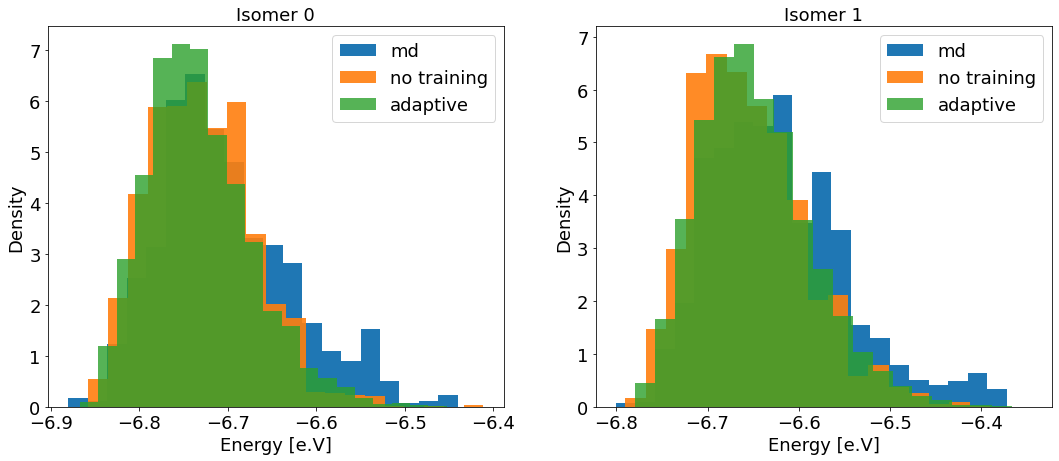

In [133]:
bins=20

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

ax[0].hist(xs_is0_md[2].detach().flatten(), bins=bins, label='md', density=True, alpha=1)
ax[0].hist(us_is0.detach().flatten(), bins=bins, label='no training', density=True, alpha=0.9)
ax[0].hist(us_is0_adaptive, bins=bins, label='adaptive', density=True, alpha=0.8)

ax[0].set_title("Isomer 0")
ax[0].legend()

ax[0].set_xlabel("Energy [e.V]")
ax[0].set_ylabel("Density")

ax[1].hist(xs_is1_md[2].detach().flatten(), bins=bins, label='md', density=True, alpha=1)
ax[1].hist(us_is1.detach().flatten(), bins=bins, label='no training', density=True, alpha=0.9)
ax[1].hist(us_is1_adaptive, bins=bins, label='adaptive', density=True, alpha=0.8)

ax[1].set_title("Isomer 1")
ax[1].legend()

ax[1].set_xlabel("Energy [e.V]")
ax[1].set_ylabel("Density")

In [134]:
import arviz as az
from arviz.utils import get_coords, _var_names

Text(0.5, 1.0, 'Isomer 1 no trained flow')

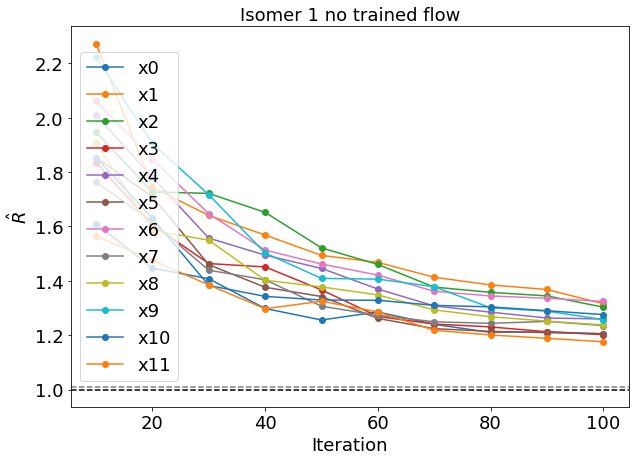

In [139]:
xs_np = mh_is1_no_training["xs"].detach().numpy()
xs_np = xs_np.transpose(1, 0, 2)

burn_in = 100

idata = az.convert_to_inference_data(xs_np[:, burn_in:, :])
coords = {}
data = get_coords(az.convert_to_dataset(idata, group="posterior"), coords)
var_names = None
filter_vars = None

var_names = _var_names(var_names, data, filter_vars)
n_draws = data.dims["draw"]
n_samples = n_draws * data.dims["chain"]
first_draw = data.draw.values[0] # int of where where things should start
labels = ['x{:d}'.format(i) for i in range(12)]

## Compute where to split the data to diagnostic the convergence
n_split = 10
xdata = np.linspace(n_samples / n_split, n_samples, n_split)
draw_divisions = np.linspace(n_draws // n_split, n_draws, n_split, dtype=int)

rhat_s = np.stack([np.array(az.rhat(data.sel(draw=slice(first_draw + draw_div)),
                    var_names=var_names,
                    method="rank",
                )['x'])
        for draw_div in draw_divisions
        ])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

axs[0].plot(draw_divisions, rhat_s, '-o',  label=labels)
axs[0].axhline(1, c='k', ls='--')
axs[0].axhline(1.01, c='grey', ls='--')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\hat{R}$')
axs[0].legend()
axs[0].set_title("Isomer 1 no trained flow")